# **Passo 1: Configuração do Ambiente e Carregamento dos Dados**

In [1]:
import pandas as pd
import numpy as np

try:

    df_transacoes = pd.read_parquet('transacoes_2022.parquet')
    df_produtos = pd.read_parquet('cadastro_produtos.parquet')
    df_pdvs = pd.read_parquet('cadastro_pdvs.parquet')

    print("Arquivos carregados com sucesso em DataFrames!")

    print("\nDimensões dos dados:")
    print(f"Transações: {df_transacoes.shape}")
    print(f"Produtos: {df_produtos.shape}")
    print(f"PDVs: {df_pdvs.shape}")

    print("\nAmostra dos dados de transações:")
    display(df_transacoes.head())

except FileNotFoundError as e:
    print(f"\nERRO: Arquivo não encontrado.")
    print("Verifique no painel de arquivos à esquerda se os nomes estão exatamente corretos e no diretório raiz ('/content/').")
    print(f"Detalhe do erro: {e}")

Arquivos carregados com sucesso em DataFrames!

Dimensões dos dados:
Transações: (6560698, 11)
Produtos: (7092, 8)
PDVs: (14419, 4)

Amostra dos dados de transações:


,internal_store_id,internal_product_id,distributor_id,transaction_date,reference_date,quantity,gross_value,net_value,gross_profit,discount,taxes
0,7384367747233276219,328903483604537190,9,2022-07-13,2022-07-01,1.0,38.125000,37.890625,10.042625,3.950000,0.234375
1,3536908514005606262,5418855670645487653,5,2022-03-21,2022-03-01,6.0,107.250000,106.440002,24.732002,17.100000,0.810000
2,3138231730993449825,1087005562675741887,6,2022-09-06,2022-09-01,3.0,56.625000,56.220001,14.124002,5.250000,0.405000
3,3681167389484217654,1401422983880045188,5,2022-09-11,2022-09-01,129.0,1037.160023,1037.160023,156.348026,479.880006,0.000000
4,7762413312337359369,6614994347738381720,4,2022-02-18,2022-02-01,1.0,26.230000,23.950241,6.550241,0.000000,2.279758


# **Passo 2: Análise e Pré-processamento**

# **2.1. Unificar os DataFrames**

In [2]:
print("Colunas em df_transacoes:", df_transacoes.columns.tolist())
print("Colunas em df_produtos:", df_produtos.columns.tolist())
print("Colunas em df_pdvs:", df_pdvs.columns.tolist())

Colunas em df_transacoes: ['internal_store_id', 'internal_product_id', 'distributor_id', 'transaction_date', 'reference_date', 'quantity', 'gross_value', 'net_value', 'gross_profit', 'discount', 'taxes']
Colunas em df_produtos: ['produto', 'categoria', 'descricao', 'tipos', 'label', 'subcategoria', 'marca', 'fabricante']
Colunas em df_pdvs: ['pdv', 'premise', 'categoria_pdv', 'zipcode']


In [3]:
df_full = pd.merge(df_transacoes, df_produtos, left_on='internal_product_id', right_on='produto', how='left')

df_full = pd.merge(df_full, df_pdvs, left_on='internal_store_id', right_on='pdv', how='left')

print("DataFrame unificado com sucesso.")
print("Colunas disponíveis:", df_full.columns.tolist())

df_full['Data'] = pd.to_datetime(df_full['transaction_date'])

print("\nColuna de data convertida.")

print("\nContagem de valores nulos por coluna:")
print(df_full.isnull().sum())

colunas_para_remover = ['internal_store_id', 'internal_product_id', 'distributor_id', 'reference_date', 'transaction_date']
df_full.drop(columns=colunas_para_remover, inplace=True, errors='ignore')

print("\nColunas desnecessárias removidas.")

df_semanal = df_full.groupby([
    pd.Grouper(key='Data', freq='W-Sun'),
    'pdv',
    'produto'
]).agg(

    quantidade=('quantity', 'sum'),
    faturamento=('gross_value', 'sum')
).reset_index()

df_semanal['ano'] = df_semanal['Data'].dt.year
df_semanal['mes'] = df_semanal['Data'].dt.month
df_semanal['semana_do_ano'] = df_semanal['Data'].dt.isocalendar().week

print("\nDados agregados por semana com sucesso!")
print("Dimensões do DataFrame semanal:", df_semanal.shape)
display(df_semanal.head())

DataFrame unificado com sucesso.
Colunas disponíveis: ['internal_store_id', 'internal_product_id', 'distributor_id', 'transaction_date', 'reference_date', 'quantity', 'gross_value', 'net_value', 'gross_profit', 'discount', 'taxes', 'produto', 'categoria', 'descricao', 'tipos', 'label', 'subcategoria', 'marca', 'fabricante', 'pdv', 'premise', 'categoria_pdv', 'zipcode']

Coluna de data convertida.

Contagem de valores nulos por coluna:
internal_store_id           0
internal_product_id         0
distributor_id              0
transaction_date            0
reference_date              0
quantity                    0
gross_value                 0
net_value                   0
gross_profit                0
discount                    0
taxes                       0
produto                     0
categoria                   0
descricao                   0
tipos                       0
label                  526953
subcategoria            10312
marca                       0
fabricante           

,Data,pdv,produto,quantidade,faturamento,ano,mes,semana_do_ano
0,2022-01-02,1020491045469449287,6766604540402338857,3.0,72.000000,2022,1,52
1,2022-01-02,1020491045469449287,7598868308473009267,3.0,373.500000,2022,1,52
2,2022-01-02,1020491045469449287,8325368510813684847,3.0,102.224998,2022,1,52
3,2022-01-02,1033408561641400708,1938760505411922162,2.0,199.000000,2022,1,52
4,2022-01-02,1033408561641400708,4623814317972718932,4.0,102.000000,2022,1,52


# **Passo 3: Engenharia de Features (Feature Engineering)**

# **3.1. Features de Lag (Atraso)**

In [4]:
df_semanal.sort_values(by=['pdv', 'produto', 'Data'], inplace=True)

lags = [1, 2, 3, 4]
for lag in lags:
    coluna_nome = f'lag_{lag}_semana'
    df_semanal[coluna_nome] = df_semanal.groupby(['pdv', 'produto'])['quantidade'].shift(lag)

print("Features de Lag criadas.")
display(df_semanal[['Data', 'pdv', 'produto', 'quantidade', 'lag_1_semana', 'lag_2_semana']].head(10))

Features de Lag criadas.


,Data,pdv,produto,quantidade,lag_1_semana,lag_2_semana
441088,2022-02-13,1000237487041964405,1837429607327399565,1.0,NaN,NaN
537470,2022-02-20,1000237487041964405,1837429607327399565,2.0,1.0,NaN
2068100,2022-05-29,1000237487041964405,1837429607327399565,1.0,2.0,1.0
2552889,2022-06-26,1000237487041964405,1837429607327399565,2.0,1.0,2.0
2925916,2022-07-17,1000237487041964405,1837429607327399565,2.0,2.0,1.0
3642753,2022-08-28,1000237487041964405,1837429607327399565,2.0,2.0,2.0
4528604,2022-10-02,1000237487041964405,1837429607327399565,1.0,2.0,2.0
5377316,2022-11-20,1000237487041964405,1837429607327399565,2.0,1.0,2.0
1585921,2022-05-01,1000237487041964405,4038588102284338370,1.0,NaN,NaN
441089,2022-02-13,1000237487041964405,5429216175252037173,2.0,NaN,NaN


# **3.2. Features de Janela Móvel (Rolling Window)**

In [5]:
df_semanal['media_movel_4_semanas'] = df_semanal.groupby(['pdv', 'produto'])['quantidade'].shift(1).rolling(window=4, min_periods=1).mean()

df_semanal['std_movel_4_semanas'] = df_semanal.groupby(['pdv', 'produto'])['quantidade'].shift(1).rolling(window=4, min_periods=1).std()

df_semanal['max_movel_4_semanas'] = df_semanal.groupby(['pdv', 'produto'])['quantidade'].shift(1).rolling(window=4, min_periods=1).max()
df_semanal['min_movel_4_semanas'] = df_semanal.groupby(['pdv', 'produto'])['quantidade'].shift(1).rolling(window=4, min_periods=1).min()

print("Features de Janela Móvel criadas.")
display(df_semanal[['Data', 'pdv', 'produto', 'quantidade', 'media_movel_4_semanas', 'std_movel_4_semanas']].head(10))

Features de Janela Móvel criadas.


,Data,pdv,produto,quantidade,media_movel_4_semanas,std_movel_4_semanas
441088,2022-02-13,1000237487041964405,1837429607327399565,1.0,NaN,NaN
537470,2022-02-20,1000237487041964405,1837429607327399565,2.0,1.000000,NaN
2068100,2022-05-29,1000237487041964405,1837429607327399565,1.0,1.500000,0.707107
2552889,2022-06-26,1000237487041964405,1837429607327399565,2.0,1.333333,0.577350
2925916,2022-07-17,1000237487041964405,1837429607327399565,2.0,1.500000,0.577350
3642753,2022-08-28,1000237487041964405,1837429607327399565,2.0,1.750000,0.500000
4528604,2022-10-02,1000237487041964405,1837429607327399565,1.0,1.750000,0.500000
5377316,2022-11-20,1000237487041964405,1837429607327399565,2.0,1.750000,0.500000
1585921,2022-05-01,1000237487041964405,4038588102284338370,1.0,1.666667,0.577350
441089,2022-02-13,1000237487041964405,5429216175252037173,2.0,1.500000,0.707107


# **3.3. Features de Data e Sazonalidade**

In [6]:
df_semanal['dia_do_mes'] = df_semanal['Data'].dt.day
df_semanal['eh_fim_de_mes'] = (df_semanal['dia_do_mes'] > 25).astype(int)
df_semanal['eh_inicio_de_mes'] = (df_semanal['dia_do_mes'] < 7).astype(int)

print("Features de Data criadas.")
display(df_semanal[['Data', 'dia_do_mes', 'eh_fim_de_mes', 'eh_inicio_de_mes']].head())

Features de Data criadas.


,Data,dia_do_mes,eh_fim_de_mes,eh_inicio_de_mes
441088,2022-02-13,13,0,0
537470,2022-02-20,20,0,0
2068100,2022-05-29,29,1,0
2552889,2022-06-26,26,1,0
2925916,2022-07-17,17,0,0


# **3.4. Incorporar e Codificar Features Categóricas**

In [7]:
df_final = pd.merge(df_semanal, df_produtos, on='produto', how='left')

df_final = pd.merge(df_final, df_pdvs, on='pdv', how='left')

colunas_categoricas = ['categoria', 'subcategoria', 'marca', 'fabricante', 'premise', 'categoria_pdv']

for col in colunas_categoricas:
    if col in df_final.columns:
        df_final[col] = df_final[col].astype('category').cat.codes

print("Features Categóricas incorporadas e codificadas.")
display(df_final[colunas_categoricas].head())

Features Categóricas incorporadas e codificadas.


,categoria,subcategoria,marca,fabricante,premise,categoria_pdv
0,4,10,1495,116,1,53
1,4,10,1495,116,1,53
2,4,10,1495,116,1,53
3,4,10,1495,116,1,53
4,4,10,1495,116,1,53


# **3.5. Limpeza Final**

In [8]:
df_final.fillna(0, inplace=True)

print("Valores nulos tratados. DataFrame final pronto para modelagem.")
display(df_final.head())

Valores nulos tratados. DataFrame final pronto para modelagem.


,Data,pdv,produto,quantidade,faturamento,ano,mes,semana_do_ano,lag_1_semana,lag_2_semana,...,categoria,descricao,tipos,label,subcategoria,marca,fabricante,premise,categoria_pdv,zipcode
0,2022-02-13,1000237487041964405,1837429607327399565,1.0,35.200001,2022,2,6,0.0,0.0,...,4,FIRE MAKER PERFECT MATCH IPA 4/6 CN,Package,Core,10,1495,116,1,53,30175
1,2022-02-20,1000237487041964405,1837429607327399565,2.0,70.400002,2022,2,7,1.0,0.0,...,4,FIRE MAKER PERFECT MATCH IPA 4/6 CN,Package,Core,10,1495,116,1,53,30175
2,2022-05-29,1000237487041964405,1837429607327399565,1.0,38.400002,2022,5,21,2.0,1.0,...,4,FIRE MAKER PERFECT MATCH IPA 4/6 CN,Package,Core,10,1495,116,1,53,30175
3,2022-06-26,1000237487041964405,1837429607327399565,2.0,76.800003,2022,6,25,1.0,2.0,...,4,FIRE MAKER PERFECT MATCH IPA 4/6 CN,Package,Core,10,1495,116,1,53,30175
4,2022-07-17,1000237487041964405,1837429607327399565,2.0,76.800003,2022,7,28,2.0,1.0,...,4,FIRE MAKER PERFECT MATCH IPA 4/6 CN,Package,Core,10,1495,116,1,53,30175


# **4. Treinamento do Modelo**

In [9]:
df_final['pdv'] = df_final['pdv'].astype(int)
df_final['produto'] = df_final['produto'].astype(int)

print("Tipos de dados de 'pdv' e 'produto' após a conversão:")
print(df_final[['pdv', 'produto']].dtypes)

Tipos de dados de 'pdv' e 'produto' após a conversão:
pdv        int64
produto    int64
dtype: object


# **4.1. Definição das Features (X) e do Alvo (y)**

In [10]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split

target = 'quantidade'

features = [col for col in df_final.columns if col not in [
    'Data',
    'quantidade',
    'faturamento',
    'descricao',
    'tipos',
    'label'
]]

X = df_final[features]
y = df_final[target]

print(f"Número de features usadas no modelo: {len(features)}")
print("Exemplo de features:", features[:5])

Número de features usadas no modelo: 23
Exemplo de features: ['pdv', 'produto', 'ano', 'mes', 'semana_do_ano']


# **4.2 - Dividir os dados, Treinar o modelo e Avaliar o modelo**


--- Treinando o Modelo LightGBM ---
Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[2000]	valid_0's l1: 2.43761

--- Avaliando a Performance do Modelo ---

--- Performance na Validação Local ---
Erro Absoluto Médio (MAE): 2.4376
WMAPE: 0.4657 (ou 46.57%)
--------------------------------------


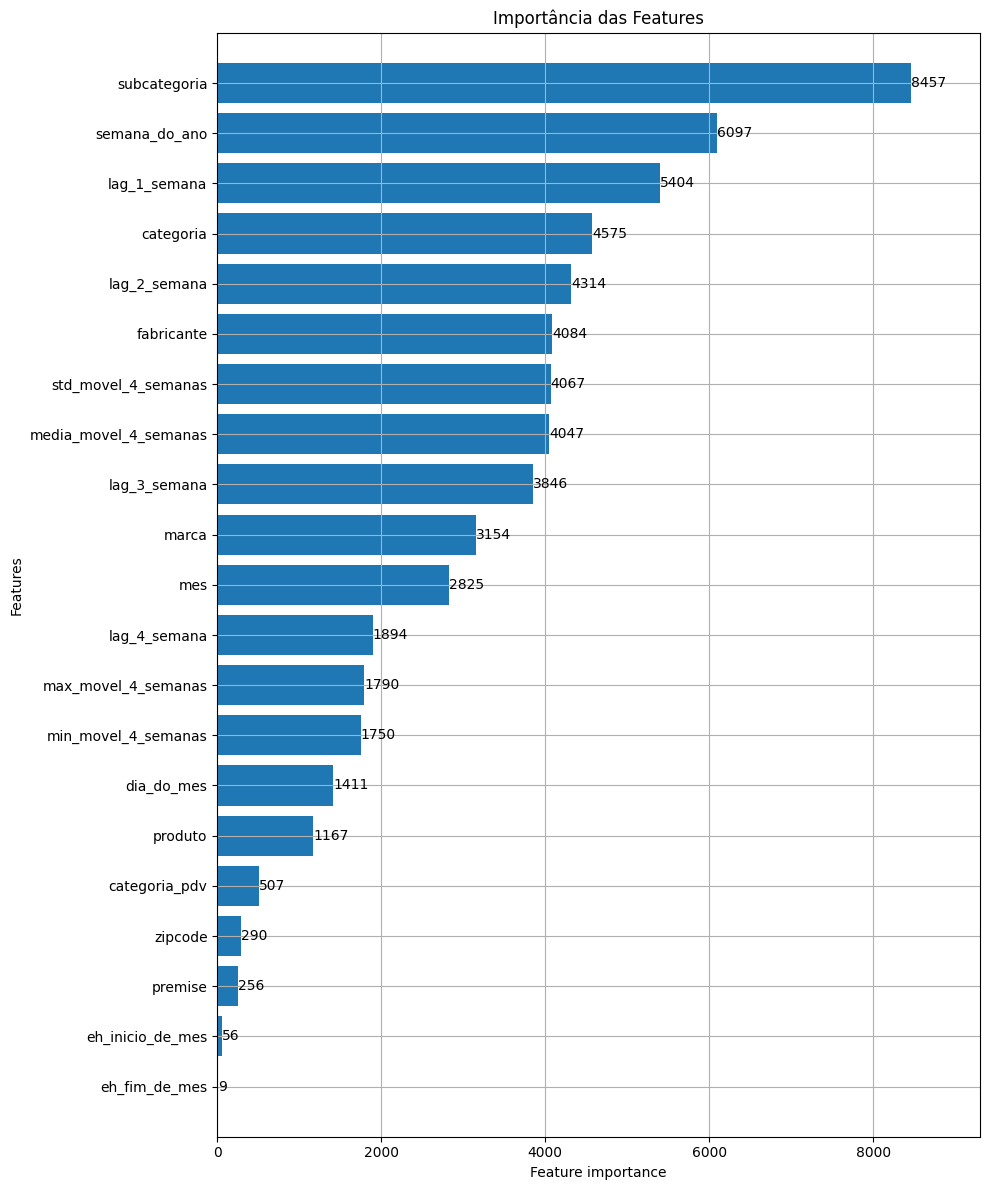

In [11]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error

target = 'quantidade'
features = [col for col in df_final.columns if col not in [
    'Data', 'quantidade', 'faturamento', 'descricao', 'tipos', 'label'
]]

X = df_final[features]
y = df_final[target]

data_final = df_final['Data'].max()
data_inicio_validacao = data_final - pd.Timedelta(weeks=4)

df_treino = df_final[df_final['Data'] < data_inicio_validacao]
df_validacao = df_final[df_final['Data'] >= data_inicio_validacao]

X_train, y_train = df_treino[features], df_treino[target]
X_val, y_val = df_validacao[features], df_validacao[target]

print("\n--- Treinando o Modelo LightGBM ---")
params = {
    'objective': 'regression_l1', 'metric': 'mae', 'n_estimators': 2000,
    'learning_rate': 0.01, 'feature_fraction': 0.8, 'bagging_fraction': 0.8,
    'bagging_freq': 1, 'lambda_l1': 0.1, 'lambda_l2': 0.1, 'num_leaves': 31,
    'verbose': -1, 'n_jobs': -1, 'seed': 42, 'boosting_type': 'gbdt',
}
model = lgb.LGBMRegressor(**params)
model.fit(X_train, y_train,
          eval_set=[(X_val, y_val)],
          eval_metric='mae',
          callbacks=[lgb.early_stopping(100, verbose=True)])

print("\n--- Avaliando a Performance do Modelo ---")
previsoes_val = model.predict(X_val)
mae = mean_absolute_error(y_val, previsoes_val)

def wmape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))

wmape_score = wmape(y_val, previsoes_val)
print(f"\n--- Performance na Validação Local ---")
print(f"Erro Absoluto Médio (MAE): {mae:.4f}")
print(f"WMAPE: {wmape_score:.4f} (ou {wmape_score*100:.2f}%)")
print("--------------------------------------")

lgb.plot_importance(model, figsize=(10, 12), max_num_features=30, height=0.8, title="Importância das Features")
plt.tight_layout()
plt.show()

# **5 - Geração das Previsões e Arquivo de Submissão**

In [12]:
print("--- 5.1. Retreinando o modelo com todos os dados de 2022 ---")
num_rodadas_otimo = model.best_iteration_
params['n_estimators'] = num_rodadas_otimo
model_final = lgb.LGBMRegressor(**params)
model_final.fit(X, y)
print(f"Modelo final treinado com sucesso usando {num_rodadas_otimo} estimadores.")

print("\n--- 5.2. Preparando estruturas para a previsão otimizada ---")

data_final_2022 = df_final['Data'].max()

data_inicio_filtro = data_final_2022 - pd.Timedelta(days=18)

df_recente = df_final[df_final['Data'] >= data_inicio_filtro]
pares_pdv_produto = df_recente[['pdv', 'produto']].drop_duplicates()
print(f"Filtro de 18 dias resultou em {len(pares_pdv_produto)} combinações PDV/Produto ativas.")
print(f"ESTIMATIVA DE LINHAS NA SUBMISSÃO FINAL: {len(pares_pdv_produto) * 5}")

datas_predicao = pd.to_datetime(['2023-01-08', '2023-01-15', '2023-01-22', '2023-01-29', '2023-02-05'])

df_predicao_base = pd.DataFrame()
for i, data in enumerate(datas_predicao, 1):
    temp_df = pares_pdv_produto.copy()
    temp_df['Data'] = data
    temp_df['semana'] = i
    df_predicao_base = pd.concat([df_predicao_base, temp_df], ignore_index=True)

features_atuais = df_final.loc[df_final.groupby(['pdv', 'produto'])['Data'].idxmax()].copy()

print("\n--- 5.3. Gerando previsões de forma iterativa e otimizada ---")
lista_previsoes = []
for i, data_semana in enumerate(datas_predicao, 1):
    print(f"Prevendo a Semana {i}/5...")
    df_pred_semana = df_predicao_base[df_predicao_base['semana'] == i].copy()
    df_pred_semana = pd.merge(df_pred_semana, features_atuais[features], on=['pdv', 'produto'], how='left')
    df_pred_semana['ano'] = df_pred_semana['Data'].dt.year
    df_pred_semana['mes'] = df_pred_semana['Data'].dt.month
    df_pred_semana['semana_do_ano'] = df_pred_semana['Data'].dt.isocalendar().week
    df_pred_semana['dia_do_mes'] = df_pred_semana['Data'].dt.day
    df_pred_semana['eh_fim_de_mes'] = (df_pred_semana['dia_do_mes'] > 25).astype(int)
    df_pred_semana['eh_inicio_de_mes'] = (df_pred_semana['dia_do_mes'] < 7).astype(int)
    df_pred_semana.fillna(0, inplace=True)
    X_pred = df_pred_semana[features]
    previsao = model_final.predict(X_pred)
    previsao[previsao < 0] = 0
    df_pred_semana['quantidade'] = np.round(previsao).astype(int)
    df_pred_semana['semana'] = i
    lista_previsoes.append(df_pred_semana[['semana', 'pdv', 'produto', 'quantidade']])
    novas_features = features_atuais.copy().set_index(['pdv', 'produto'])
    previsao_map = df_pred_semana.set_index(['pdv', 'produto'])['quantidade']
    novas_features['lag_4_semana'] = novas_features['lag_3_semana']
    novas_features['lag_3_semana'] = novas_features['lag_2_semana']
    novas_features['lag_2_semana'] = novas_features['lag_1_semana']
    novas_features['lag_1_semana'] = previsao_map
    novas_features['media_movel_4_semanas'] = novas_features[['lag_1_semana', 'lag_2_semana', 'lag_3_semana', 'lag_4_semana']].mean(axis=1)
    features_atuais = novas_features.reset_index()

print("\n--- 5.4. Salvando o arquivo de submissão ---")
df_submissao = pd.concat(lista_previsoes, ignore_index=True)
print("Amostra do arquivo de submissão:")
display(df_submissao.head())
print(f"Total de linhas na submissão FINAL: {df_submissao.shape[0]}")
df_submissao.to_parquet('submissao.parquet', index=False)
print("\nArquivo 'submissao.parquet' criado com sucesso!")

--- 5.1. Retreinando o modelo com todos os dados de 2022 ---
Modelo final treinado com sucesso usando 2000 estimadores.

--- 5.2. Preparando estruturas para a previsão otimizada ---
Filtro de 18 dias resultou em 266721 combinações PDV/Produto ativas.
ESTIMATIVA DE LINHAS NA SUBMISSÃO FINAL: 1333605

--- 5.3. Gerando previsões de forma iterativa e otimizada ---
Prevendo a Semana 1/5...
Prevendo a Semana 2/5...
Prevendo a Semana 3/5...
Prevendo a Semana 4/5...
Prevendo a Semana 5/5...

--- 5.4. Salvando o arquivo de submissão ---
Amostra do arquivo de submissão:


,semana,pdv,produto,quantidade
0,1,1001371918471115422,1009179103632945474,1
1,1,1001371918471115422,1120490062981954254,11
2,1,1001371918471115422,1394381856358939027,15
3,1,1001371918471115422,1454838625590783593,3
4,1,1001371918471115422,1625722803643187564,1


Total de linhas na submissão FINAL: 1333605

Arquivo 'submissao.parquet' criado com sucesso!
